<a href="https://colab.research.google.com/github/haaniyaafaheemaa/haaniyaa-codeboosters-2026/blob/main/Day-02/MiniProject_Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('student_performance.csv')

conn = sqlite3.connect('college.db')
cursor = conn.cursor()

df.to_sql("students", conn, if_exists="replace", index=False)


def run_query(sql,description="students"):
  if description:
    print(f"{description}")

  result=pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result

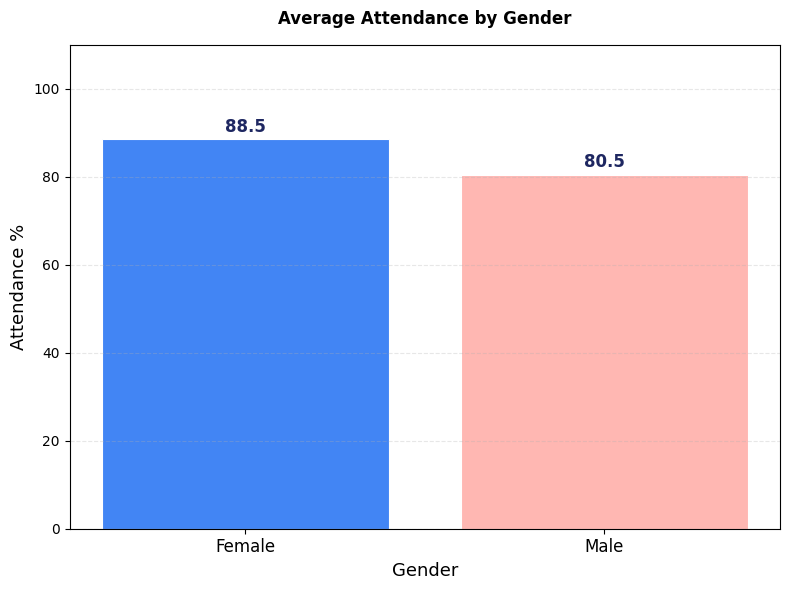

In [19]:
chart1_sql = """
SELECT gender, ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY gender
"""
chart1_data =  pd.read_sql_query(chart1_sql,conn)

fig, ax = plt.subplots(figsize=(8, 6))
bar_colors = ['#4285F4', '#FFB7B2', '#A9A9A9', '#9966CC']
bars = ax.bar(chart1_data['gender'],
              chart1_data['avg_attendance'],
              color=bar_colors,
              edgecolor = 'white',
              linewidth = 0.8)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.8,
        f'{height:.1f}',
        ha='center', va='bottom',
        fontsize = 12, fontweight = 'bold',
        color = '#1E2761')

ax.set_xlabel('Gender', fontsize = 13)
ax.set_ylabel('Attendance %', fontsize = 13)
ax.set_title('Average Attendance by Gender',fontsize = 12, fontweight = 'bold', pad = 15)
ax.set_ylim(0,110)
ax.tick_params(axis='x', labelsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


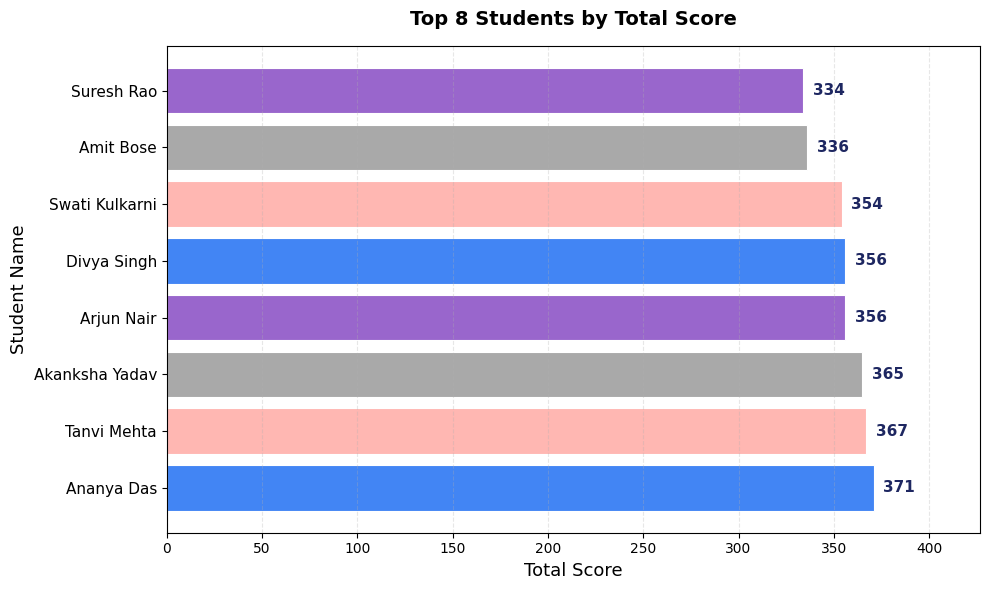

In [36]:
chart2_sql = """
SELECT name, (programming_score + math_score + science_score + english_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""
chart2_data = pd.read_sql_query(chart2_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#4285F4', '#FFB7B2', '#A9A9A9', '#9966CC']

bars = ax.barh(chart2_data['name'],
               chart2_data['total_score'],
               color=bar_colors,
               edgecolor='white',
               linewidth=0.8)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 5,
        bar.get_y() + bar.get_height()/2,
        f'{width:.0f}',
        ha='left', va='center',
        fontsize=11, fontweight='bold',
        color='#1E2761')

ax.set_xlabel('Total Score', fontsize=13)
ax.set_ylabel('Student Name', fontsize=13)
ax.set_title('Top 8 Students by Total Score', fontsize=14, fontweight='bold', pad=15)
max_possible_score = chart2_data['total_score'].max()
ax.set_xlim(0, max_possible_score * 1.15)

ax.tick_params(axis='y', labelsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.3)


plt.tight_layout()
plt.show()
